In [1]:
# 이 노트북 실행에 필요한 패키지 설치 (최초 1회 실행)
# %pip 은 현재 노트북 커널과 같은 Python에 설치합니다. 설치 후 커널 재시작 권장.
%pip install torch pandas numpy kiwipiepy sentencepiece nltk transformers tqdm matplotlib seaborn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Project: 멋진 챗봇 만들기

In [2]:
# Standard Transformer 대비 GPT 아키텍처 변경 사항

# 1.  Decoder-Only 구조: 기존의 Encoder-Decoder Seq2Seq 구조에서 Encoder를 완전히 제거하고, Decoder 부분만을 사용하여 단방향(Causal) 생성 모델로 변경했습니다.
# 2.  Cross-Attention 제거: Encoder가 제거됨에 따라 DecoderLayer 내부에 존재하던 enc_out과 encdec_mask를 참조하는 Encoder-Decoder Attention(Cross-Attention) 레이어를 삭제했습니다.
# 3.  활성화 함수 변경: 기존의 ReLU 대신 GPT-1에서 제안한 GELU (Gaussian Error Linear Unit) 활성화 함수를 사용하여 비선형성을 강화했습니다.
# 4.  Learned Position Embedding: 기존의 고정된 Sinusoidal 방식이 아닌, 학습 가능한 Embedding Layer 기반의 위치 정보를 사용합니다.
# 5.  입력 구조 변경 (Traversal Style): 텍스트 분류, 함의, 유사도 등 다양한 작업을 위해 START, DELIM, EXTRACT와 같은 특수 토큰을 삽입하여 입력을 단일 시퀀스로 통합 처리합니다.

In [3]:
# 이 노트북 실행에 필요한 패키지 설치 (최초 1회 실행)
# %pip 은 현재 노트북 커널과 같은 Python에 설치합니다. 설치 후 커널 재시작 권장.
%pip install torch pandas numpy kiwipiepy sentencepiece nltk transformers tqdm matplotlib seaborn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 0. 환경 구성

In [4]:
# =========================================
# 0. 환경 설정 & 라이브러리 임포트
# 챗봇 학습·실험에 필요한 라이브러리를 불러옵니다.
# =========================================
import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from kiwipiepy import Kiwi            # 한글 형태소 분석 (문장 → 단어/형태소 단위 분리)
import sentencepiece as spm
from tqdm import tqdm                # 진행률 표시
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction  # BLEU 점수 계산

from transformers import get_cosine_schedule_with_warmup  # 학습률 스케줄 (warmup + cosine decay)

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager
import platform
import os
import warnings


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

# 한글 폰트 관련 경고 무시 (시각화 시 글자 깨짐 방지)
warnings.filterwarnings("ignore", message="Glyph 9601", module="seaborn.utils")
warnings.filterwarnings("ignore", message="Glyph 9601", module="IPython.core.pylabtools")

# OS별 한글 폰트 설정 (그래프·시각화에서 한글이 올바르게 표시되도록)
system = platform.system()
if system == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    pass
mpl.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 연산 장치 선택: GPU(cuda)가 있으면 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [6]:
# 재현성을 위해 난수 시드 고정 (같은 설정이면 동일한 결과를 얻기 위함)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    

### 1. 데이터 적재 및 전처리

In [7]:
# =========================================
# 1. 데이터 로드 & 전처리 (Chatbot_data.csv)
# 질문(Q)-답변(A) 쌍이 담긴 CSV를 불러와서 사용할 컬럼만 정리합니다.
# =========================================
DATA_PATH = "./data/ChatbotData.csv"
# 현재/상위 폴더에서 data/ChatbotData.csv 위치 탐색
if not os.path.exists(DATA_PATH):
    # cwd가 프로젝트 폴더가 아닐 수 있음 → 상위 디렉터리에서 검색
    d = os.getcwd()
    for _ in range(5):
        trial = os.path.join(d, "data", "ChatbotData.csv")
        if os.path.exists(trial):
            DATA_PATH = trial
            os.chdir(d)
            break
        d = os.path.dirname(d)
        if not d:
            break
if not os.path.exists(DATA_PATH):
    # 홈 아래 프로젝트 경로 fallback (cwd가 ~ 일 때)
    home = os.path.expanduser("~")
    for base in [
        os.path.join(home, "내 드라이브(darkaruna78@gmail.com)", "modulab", "Data_Quset", "05 transformer_TM_개인버전"),
        os.path.join(home, "Google Drive", "내 드라이브(darkaruna78@gmail.com)", "modulab", "Data_Quset", "05 transformer_TM_개인버전"),
    ]:
        trial = os.path.join(base, "data", "ChatbotData.csv")
        if os.path.exists(trial):
            DATA_PATH = trial
            os.chdir(base)
            break
assert os.path.exists(DATA_PATH), f"ChatbotData.csv 준비 필요! (현재 cwd: {os.getcwd()})"

df = pd.read_csv(DATA_PATH)
# 질문(Q), 답변(A) 컬럼만 사용하고, 빈 값이 있는 행은 제거
df = df[["Q", "A"]].dropna()

print("원본 데이터 개수:", len(df))

원본 데이터 개수: 11823


In [8]:
# -----------------------------------------
# 1-1. 한글 정규화 & 기본 전처리 함수
# 특수문자 제거·공백 정리로 모델이 다루기 쉬운 텍스트 형태로 만듭니다.
# -----------------------------------------
def clean_korean_text(text: str) -> str:
    text = str(text).strip()
    # 한글, 숫자, 영문, ?!., 공백만 남기고 나머지는 공백으로 치환
    text = re.sub(r"[^ㄱ-ㅎ가-힣0-9a-zA-Z\?\!\.\,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Q_clean"] = df["Q"].apply(clean_korean_text)
df["A_clean"] = df["A"].apply(clean_korean_text)

# 너무 짧거나 긴 문장 제외 (품질·길이 균형)
df = df[(df["Q_clean"].str.len() >= 2) & (df["Q_clean"].str.len() <= 50)]
df = df[(df["A_clean"].str.len() >= 2) & (df["A_clean"].str.len() <= 50)]

print("1차 정제 후 개수:", len(df))

1차 정제 후 개수: 11787


### 2. 형태소 분석 및 토큰 수준 정제

In [9]:
# =========================================
# 2. 형태소 분석 + 토큰 수준 정제 (Kiwi)
# 문장을 형태소(의미 단위)로 분리합니다. 예: '하루가' → '하루', '가'
# =========================================
if "Q_clean" not in df.columns:
    if "Q" not in df.columns:
        raise KeyError("'Q_clean' 또는 'Q'가 없습니다. 먼저 '1. 데이터 전처리' 셀을 실행하세요.")
    _clean = globals().get("clean_korean_text")
    if callable(_clean):
        df["Q_clean"] = df["Q"].apply(_clean)
        df["A_clean"] = df["A"].apply(_clean)
    else:
        df["Q_clean"] = df["Q"].astype(str).str.strip()
        df["A_clean"] = df["A"].astype(str).str.strip()
    df = df[(df["Q_clean"].str.len() >= 2) & (df["Q_clean"].str.len() <= 50)]
    df = df[(df["A_clean"].str.len() >= 2) & (df["A_clean"].str.len() <= 50)]
    print("주의: '1. 데이터 전처리' 셀을 먼저 실행하면 더 좋습니다. Q/A로부터 Q_clean을 생성했습니다.")

kiwi = Kiwi()  # Kiwi 형태소 분석기 로드

def kiwi_tokenize(text: str):
    """문장을 형태소 단위로 분리. 품사(명사 NN, 동사 VV, 형용사 VA 등)별로 토큰 추출."""
    tokens = []
    for tok, pos, _, _ in kiwi.analyze(text, top_n=1)[0][0]:
        if pos.startswith("NN") or pos.startswith("VV") or pos.startswith("VA") or pos.startswith("MAG") or pos.startswith("IC"):
            tokens.append(tok)
        else:
            tokens.append(tok)
    if len(tokens) < 2:
        return text.split()  # 토큰이 너무 적으면 공백 기준 분리
    return tokens

def join_tokens(tokens):
    """토큰 리스트를 공백으로 이어 하나의 문장 문자열로 만듦."""
    return " ".join(tokens)

df["Q_tok"] = df["Q_clean"].apply(kiwi_tokenize)
df["A_tok"] = df["A_clean"].apply(kiwi_tokenize)

# 토큰 리스트를 공백 구분 문장으로 합침 (이후 SentencePiece 학습에 사용)
df["Q_proc"] = df["Q_tok"].apply(join_tokens)
df["A_proc"] = df["A_tok"].apply(join_tokens)

print("토큰 예시 Q:", df["Q_proc"].iloc[0])
print("토큰 예시 A:", df["A_proc"].iloc[0])

Quantization is not supported for ArchType::neon. Fall back to non-quantized model.


토큰 예시 Q: 12 시 땡 !
토큰 예시 A: 하루 가 또 가 네요 .


### 3. 데이터 증강

In [10]:
# =========================================
# 3. 데이터 증강 (augmentation)
# 원본 질문-답변 쌍에 단어 드랍·순서 스왑을 적용해 데이터 수를 늘립니다.
# 목표: 약 3만 개의 (질문, 답변) 쌍 확보.
# =========================================
# Q_proc가 없으면 이전 셀을 건너뛴 것이므로 Q_clean 등으로 대체
if "Q_proc" not in df.columns:
    if "Q_clean" not in df.columns:
        raise KeyError("'Q_clean'이 없습니다. 먼저 '1. 데이터 전처리' 셀을 실행하세요.")
    if "Q_proc" not in df.columns and "kiwi_tokenize" in dir() and callable(globals().get("kiwi_tokenize")):
        df["Q_tok"] = df["Q_clean"].apply(kiwi_tokenize)
        df["A_tok"] = df["A_clean"].apply(kiwi_tokenize)
        df["Q_proc"] = df["Q_tok"].apply(join_tokens)
        df["A_proc"] = df["A_tok"].apply(join_tokens)
    else:
        df["Q_proc"] = df["Q_clean"]
        df["A_proc"] = df["A_clean"]
        print("주의: '2. 형태소 분석' 셀을 먼저 실행하면 더 좋습니다. Q_clean으로 대체합니다.")
pairs = list(zip(df["Q_proc"].tolist(), df["A_proc"].tolist()))
print("원본 쌍 개수:", len(pairs))

def random_drop_tokens(tokens, drop_prob=0.05):
    """각 토큰을 일정 확률로 제거 (문장 변형)."""
    if len(tokens) <= 3:
        return tokens
    new_tokens = [t for t in tokens if random.random() >= drop_prob]
    return new_tokens if len(new_tokens) >= 2 else tokens

def random_swap_tokens(tokens, swap_prob=0.05):
    """인접한 토큰을 일정 확률로 서로 바꿈 (어순 변형)."""
    tokens = tokens[:]
    n = len(tokens)
    for i in range(n - 1):
        if random.random() < swap_prob:
            j = min(n - 1, i + 1)
            tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens

aug_pairs = []

for q, a in pairs:
    aug_pairs.append((q, a))  # 원본

    # 1) Q 토큰 드랍
    q_toks = q.split()
    a_toks = a.split()
    q_drop = " ".join(random_drop_tokens(q_toks))
    aug_pairs.append((q_drop, a))

    # 2) A 토큰 드랍
    a_drop = " ".join(random_drop_tokens(a_toks))
    aug_pairs.append((q, a_drop))

    # 3) Q/A 둘 다 스왑
    q_swap = " ".join(random_swap_tokens(q_toks))
    a_swap = " ".join(random_swap_tokens(a_toks))
    aug_pairs.append((q_swap, a_swap))

# 중복 제거
aug_pairs = list(set(aug_pairs))
print("증강 후 쌍 개수:", len(aug_pairs))

# 3만 개 가까이 맞추기 (필요시 샘플링)
TARGET_SIZE = 30000
if len(aug_pairs) > TARGET_SIZE:
    aug_pairs = random.sample(aug_pairs, TARGET_SIZE)

print("최종 사용 쌍 개수:", len(aug_pairs))

원본 쌍 개수: 11787
증강 후 쌍 개수: 25857
최종 사용 쌍 개수: 25857


### 4. 토크나이저 학습

In [24]:
# =========================================
# 4. SentencePiece 토크나이저 학습
# 질문·답변 문장들을 모아 서브워드 단위 vocab을 학습합니다.
# 학습된 토크나이저로 문장 → 숫자 id 시퀀스로 변환할 수 있습니다.
# =========================================
SPM_MODEL_PREFIX = "chatbot_spm"
VOCAB_SIZE = 2768  # 단어 개수. SentencePiece 제한(<=2768) 이내. 너무 크면 과적합, 너무 작으면 표현력 부족

# 증강된 질문·답변 문장을 한 줄씩 저장 (토크나이저 학습 입력)
corpus_file = "chatbot_corpus.txt"
with open(corpus_file, "w", encoding="utf-8") as f:
    for q, a in aug_pairs:
        f.write(q + "\n")
        f.write(a + "\n")
    

# user_defined_symbols=[DELIM]: 구분자를 vocab에 예약해 두면 GetPieceSize() 밖 ID를 쓸 필요 없음.
# → DecodeIds/IdToPiece 시 범위 초과 에러 없음, VOCAB_SIZE_GPT = GetPieceSize() 로 통일.
spm.SentencePieceTrainer.Train(
    f"--input={corpus_file} "
    f"--model_prefix={SPM_MODEL_PREFIX} "
    f"--vocab_size={VOCAB_SIZE} "
    f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3 "
    f"--user_defined_symbols=[DELIM]"
)
tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(f"{SPM_MODEL_PREFIX}.model")
print("Vocab size:", tokenizer.GetPieceSize())

Vocab size: 2768


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=chatbot_corpus.txt --model_prefix=chatbot_spm --vocab_size=2768 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3 --user_defined_symbols=[DELIM]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_spm
  model_type: UNIGRAM
  vocab_size: 2768
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [DELIM]
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed

### 5. 토큰화 + 패딩 텐서 생성

In [25]:
# =========================================
# 5. 토큰화 + 패딩 (Traversal Style)
# GPT 스타일: [시작] + 질문토큰 + [구분자] + 답변토큰 + [끝] 형태로 한 줄 시퀀스 구성.
# =========================================
ID_START, ID_END = 1, 2  # 문장 시작/끝 토큰 (BOS, EOS)
# 학습 시 --user_defined_symbols=[DELIM] 으로 넣었으므로 vocab 안의 ID로 조회
DELIM_ID = tokenizer.PieceToId("[DELIM]")  # 질문·답변 구분자 (SentencePiece vocab 내부)
MAX_LEN = 81  # 전체 시퀀스 최대 길이 (질문+구분자+답변)

def encode_sentence(text):
    """문장을 토크나이저로 숫자 id 리스트로 변환."""
    return tokenizer.EncodeAsIds(text)

seq_corpus = []
for q, a in tqdm(aug_pairs, desc="Encoding"):
    q_ids = encode_sentence(q)
    a_ids = encode_sentence(a)
    seq = [ID_START] + q_ids + [DELIM_ID] + a_ids + [ID_END]
    if len(seq) > MAX_LEN:
        continue
    seq_corpus.append(seq)

print("길이 제한 후 쌍 개수:", len(seq_corpus))

def pad_sequences(seqs, maxlen, pad_value=0):
    """시퀀스 리스트를 같은 길이로 맞추고 (짧으면 0으로 채움) 텐서로 변환."""
    padded = []
    for s in seqs:
        if len(s) > maxlen:
            s = s[:maxlen]
        padded.append(s + [pad_value] * (maxlen - len(s)))
    return torch.tensor(padded, dtype=torch.long)

seq_ndarray = pad_sequences(seq_corpus, MAX_LEN, pad_value=0)
print("seq shape:", seq_ndarray.shape)
# [DELIM]이 user_defined_symbols로 vocab에 포함되어 있으므로 +1 불필요
VOCAB_SIZE_GPT = tokenizer.GetPieceSize()
dataset = TensorDataset(seq_ndarray)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, pin_memory=True)  # 미니배치 로더


Encoding: 100%|██████████| 25857/25857 [00:00<00:00, 96623.04it/s] 


길이 제한 후 쌍 개수: 25857
seq shape: torch.Size([25857, 81])


### 6. GPT 모델 정의

In [26]:
# =========================================
# 6. GPT 모델 정의
# Decoder만 사용하는 단방향 언어 모델. dropout·shared embedding으로 과적합 완화.
# =========================================
class MultiHeadAttention(nn.Module):
    """여러 개의 attention head로 Query, Key, Value를 처리해 문맥 정보를 모음."""
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads  # head 하나당 차원
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Q·K 유사도로 가중치를 구한 뒤 V에 적용. mask로 패딩·미래 위치 가림."""
        dk = K.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)
        if mask is not None:
            scores = scores.masked_fill(mask == 1, -1e9)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)
        return out, attn

    def split_heads(self, x):
        """(B, L, D) → (B, head수, L, head당 차원) 으로 나눔."""
        B, L, D = x.size()
        x = x.view(B, L, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """다시 (B, L, D) 형태로 합침."""
        B, H, L, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        Q, K, V = self.Wq(Q), self.Wk(K), self.Wv(V)
        Qh, Kh, Vh = self.split_heads(Q), self.split_heads(K), self.split_heads(V)
        out, attn = self.scaled_dot_product_attention(Qh, Kh, Vh, mask)
        out = self.linear(self.combine_heads(out))
        return out, attn


In [15]:
class PoswiseFeedForwardNet(nn.Module):
    """위치별 2층 MLP. 차원 확장 후 GELU로 비선형 적용 후 다시 원래 차원으로."""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        # GELU 사용 (GPT-1)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))

class DecoderLayer(nn.Module):
    """디코더 한 층: Masked Self-Attention + FFN. (이전 위치만 참조)"""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, dec_mask):
        residual = x
        x = self.norm1(x)
        x, self_attn = self.self_attn(x, x, x, dec_mask)
        x = self.dropout(x) + residual
        residual = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x) + residual
        return x, self_attn


In [27]:
class Decoder(nn.Module):
    """DecoderLayer를 n_layers만큼 쌓은 스택. 입력 시퀀스에서 다음 토큰 예측에 사용."""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, dec_mask):
        attns = []
        for layer in self.layers:
            x, sa = layer(x, dec_mask)
            attns.append(sa)
        return x, attns

# 위치 정보는 GPT 안에서 nn.Embedding(Learned)으로 처리


In [28]:
class GPT(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 max_len,
                 dropout=0.3,
                 shared_emb=True,
                 shared_fc=True):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_emb = nn.Embedding(max_len, d_model)  # 위치별 학습 가능한 임베딩
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

        self.dropout = nn.Dropout(dropout)

    def embed(self, emb, x):
        # 토큰 id → 임베딩 벡터, 스케일 후 위치 임베딩을 더함
        B, L = x.size()
        out = emb(x) * math.sqrt(self.d_model)
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        out = out + self.pos_emb(pos)
        return self.dropout(out)

    def forward(self, seq, dec_mask):
        # seq (B,L) → 각 위치에서 다음 토큰 logits (B,L,vocab_size)
        x = self.embed(self.dec_emb, seq)
        dec_out, dec_attns = self.decoder(x, dec_mask)
        logits = self.fc(dec_out)
        return logits, dec_attns

### 7. 마스크 생성

In [29]:
# =========================================
# 7. 마스크 생성 함수
# 패딩 위치 가림 + causal(미래 토큰 가림) → 디코더에서 사용할 마스크 생성.
# =========================================
def generate_padding_mask(seq):
    """패딩(0)인 위치를 1로 표시. shape (B,L) → (B,1,1,L)."""
    mask = (seq == 0).unsqueeze(1).unsqueeze(2)
    return mask  # float/byte 상관 없이 0/1

def generate_causal_mask(size):
    """상삼각 행렬: i번째 위치가 j>i 위치를 보지 못하도록 1로 표시."""
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(seq):
    """패딩 마스크와 causal 마스크를 합쳐 (B,1,L,L) 디코더 마스크 반환."""
    dec_padding = generate_padding_mask(seq)
    L = seq.size(1)
    causal = generate_causal_mask(L).to(seq.device).unsqueeze(0).unsqueeze(1)
    dec_mask = torch.max(dec_padding, causal)
    return dec_mask

In [19]:
# -----------------------------------------
# 7-1. Attention 시각화
# 지정한 layer/head의 Decoder Self-Attention 가중치를 히트맵으로 표시.
# -----------------------------------------
def visualize_attention(tokens, dec_attns, layer=0, head=0):
    attn = dec_attns[layer][0, head].detach().cpu().numpy()
    def effective(tok):
        return [t.replace(' ', ' ') if hasattr(t, 'replace') else str(t) for t in tok if t != "<pad>"]
    tokens = effective(tokens)
    L = len(tokens)
    attn = attn[:L, :L]
    plt.figure(figsize=(8, 6))
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, square=True, cmap="Blues", vmin=0.0, vmax=1.0)
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.title(f"Decoder Self-Attention (Layer {layer+1}, Head {head+1})")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


### 8. 학습 준비

In [30]:
# =========================================
# 8. 하이퍼파라미터 · 모델 · 옵티마이저 · Loss
# 모델 크기, 학습 횟수, 학습률 스케줄, 손실 함수를 설정합니다.
# =========================================
# --- 참고: 이전 설정 (주석) ---
# d_model = 256
# n_layers = 2
# n_heads = 8
# d_ff = 4 * d_model
# dropout = 0.1
# EPOCHS = 10
# lr=5e-4, warmup 6%, label_smoothing=0.1

# --- GPU 제한 환경용 (2025-03 적용) ---
d_model = 256
n_layers = 2
n_heads = 8
d_ff = 4 * d_model
dropout = 0.15         # 0.1→0.15: 과적합 완화
EPOCHS = 15            # 10→15: 더 학습

# 모델 생성 (vocab 크기는 DELIM 포함한 VOCAB_SIZE_GPT 사용)
# 실행 순서: '5. 토큰화+패딩' 셀(VOCAB_SIZE_GPT, MAX_LEN 정의) → '6. GPT 모델 정의' 셀들 → 이 셀
model = GPT(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE_GPT,
    tgt_vocab_size=VOCAB_SIZE_GPT,
    max_len=MAX_LEN,
    dropout=dropout,
    shared_emb=True,
    shared_fc=True
).to(device)

# base_optimizer = torch.optim.AdamW(..., lr=5e-4, ...)
base_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=4e-4, betas=(0.9, 0.98), eps=1e-9, weight_decay=1e-2  # lr 5e-4→4e-4
)

# 학습률: 처음에는 warmup으로 올리고, 이후 cosine으로 서서히 감소
steps_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
num_training_steps = steps_per_epoch * EPOCHS
# num_warmup_steps = int(0.06 * num_training_steps)
num_warmup_steps = int(0.08 * num_training_steps)  # 6%→8%: 초기 안정

scheduler = get_cosine_schedule_with_warmup(
    base_optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# 패딩(0) 위치는 손실에서 제외. label_smoothing으로 과적합 완화
loss_object = nn.CrossEntropyLoss(
    reduction="none",
    ignore_index=0,
    label_smoothing=0.1  # 유지
)

def loss_function(real, pred):
    """다음 토큰 정답(real)과 예측 logits(pred)로 CrossEntropy. 패딩은 mask로 제외."""
    B, L, V = pred.size()
    pred = pred.reshape(B * L, V)
    real = real.reshape(B * L)
    loss = loss_object(pred, real)
    mask = (real != 0).float()
    return loss.sum() / mask.sum()


### 9. 학습 루프

[Epoch 1] lr(start) = 0.000000e+00


Epoch 1:   0%|          | 0/809 [00:00<?, ?it/s]

seq min / max: 0 2212
VOCAB_SIZE_GPT: 2768


Epoch 1: 100%|██████████| 809/809 [01:30<00:00,  8.90it/s]


[Epoch 1] Train Loss: 2300.9498
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 저 가 있 어요 .
----------------------
Q: 너는 누구니?
A: 저 가 있 어요 .
----------------------
Q: 점심 뭐 먹을까?
A: 저 가 있 ᆯ 수 있 ᆯ
----------------------
[Epoch 2] lr(start) = 3.336082e-04


...

[Epoch 13] Train Loss: 20.6896
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 사랑 이 예요 .
----------------------
Q: 너는 누구니?
A: 좋 어요 .
----------------------
Q: 점심 뭐 먹을까?
A: 하 어 보 세요 .
----------------------
[Epoch 14] lr(start) = 2.037159e-05


Epoch 14: 100%|██████████| 809/809 [01:28<00:00,  9.17it/s]


[Epoch 14] Train Loss: 20.2808
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 잘 하 어 보 세요 .
----------------------
Q: 너는 누구니?
A: 이제 는 것 이 있 어요 .
----------------------
Q: 점심 뭐 먹을까?
A: 저 이 예요 .
----------------------
[Epoch 15] lr(start) = 5.159447e-06


Epoch 15: 100%|██████████| 809/809 [01:27<00:00,  9.25it/s]


[Epoch 15] Train Loss: 20.1793
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 그 어 보 세요 .
----------------------
Q: 너는 누구니?
A: 저 가 나 보 어요 .
----------------------
Q: 점심 뭐 먹을까?
A: 묻 어 보 세요 .
----------------------


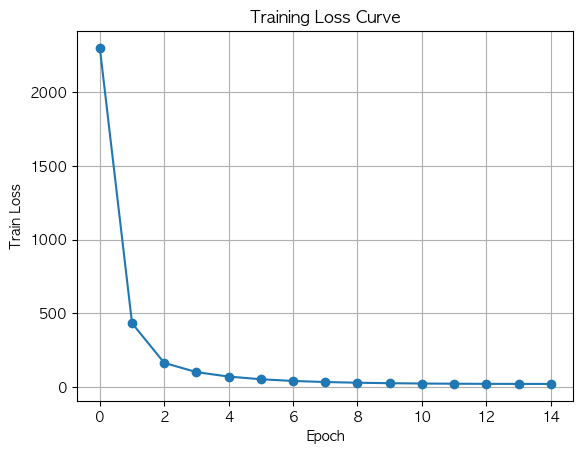

In [31]:
# =========================================
# 9. 학습 루프
# 매 에폭마다 전체 데이터로 학습하고, 예시 질문에 대한 답변을 출력해 봅니다.
# =========================================
examples = [
    "오늘 기분이 어때?",
    "너는 누구니?",
    "점심 뭐 먹을까?",
]

def sample_next_id(logits, temperature=0.8, top_k=20):
    """다음 토큰을 확률적으로 샘플링. temperature로 다양성, top_k로 상위 k개만 고려."""
    logits = logits / temperature
    if top_k is not None and top_k > 0:
        values, indices = torch.topk(logits, top_k)
        probs = torch.zeros_like(logits)
        probs.scatter_(0, indices, F.softmax(values, dim=0))
    else:
        probs = F.softmax(logits, dim=0)
    return torch.multinomial(probs, num_samples=1).item()

def reply_greedy(query, max_len=MAX_LEN):
    """질문을 [START]+Q+[DELIM] 형태로 넣고, 끝 토큰 나올 때까지 argmax로 답 생성."""
    model.eval()
    with torch.no_grad():
        q_clean = clean_korean_text(query)
        q_tokens = kiwi_tokenize(q_clean)
        q_join = join_tokens(q_tokens)
        q_ids = encode_sentence(q_join)
        prefix = [ID_START] + q_ids + [DELIM_ID]
        out_ids = prefix[:]
        for _ in range(max_len - len(prefix)):
            seq_t = torch.tensor([out_ids + [0] * (max_len - len(out_ids))], dtype=torch.long, device=device)
            dec_mask = generate_masks(seq_t)
            logits, _ = model(seq_t, dec_mask)
            next_id = logits[0, len(out_ids) - 1].argmax(dim=-1).item()
            if next_id == ID_END:
                break
            out_ids.append(next_id)
        # [DELIM]이 vocab에 있으므로 모든 id가 DecodeIds 범위 내
        return tokenizer.DecodeIds(out_ids[len(prefix):])

def generate_with_attention(query, max_len=MAX_LEN):
    """질문으로 답변 생성 + 마지막 step의 Decoder Attention 반환 (시각화용)."""
    model.eval()
    with torch.no_grad():
        q_clean = clean_korean_text(query)
        q_tokens = kiwi_tokenize(q_clean)
        q_join = join_tokens(q_tokens)
        q_ids = encode_sentence(q_join)
        prefix = [ID_START] + q_ids + [DELIM_ID]
        out_ids = prefix[:]
        repeat_cnt, max_repeat, window = 0, 3, 4
        last_dec_attns = None
        for _ in range(max_len - len(prefix)):
            seq_t = torch.tensor([out_ids + [0] * (max_len - len(out_ids))], dtype=torch.long, device=device)
            dec_mask = generate_masks(seq_t)
            logits, dec_attns = model(seq_t, dec_mask)
            last_dec_attns = dec_attns
            next_id = sample_next_id(logits[0, len(out_ids) - 1], temperature=0.8, top_k=20)
            recent = out_ids[-window:]
            repeat_cnt = repeat_cnt + 1 if next_id in recent else 0
            if next_id == ID_END or repeat_cnt >= max_repeat:
                break
            out_ids.append(next_id)
        # [DELIM]이 user_defined_symbols로 vocab에 있으므로 DecodeIds/IdToPiece 그대로 사용 가능
        decoded = tokenizer.DecodeIds(out_ids[len(prefix):])
        pad_seq = out_ids + [0] * (max_len - len(out_ids))
        src_pieces = tokenizer.IdToPiece(prefix)
        tgt_pieces = tokenizer.IdToPiece(out_ids[len(prefix):])
        seq_pieces = tokenizer.IdToPiece(pad_seq)
        return decoded, src_pieces, tgt_pieces, last_dec_attns, seq_pieces

epoch_losses = []
global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    step = 0
    current_lr = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch}] lr(start) = {current_lr:.6e}")

    # 미니배치마다: 시퀀스 입력 → 다음 토큰 예측 → 손실 역전파
    for (seq,) in tqdm(train_loader, desc=f"Epoch {epoch}"):
        seq = seq.to(device)
        if step == 0 and epoch == 1:
            print("seq min / max:", seq.min().item(), seq.max().item())
            print("VOCAB_SIZE_GPT:", VOCAB_SIZE_GPT)
        dec_mask = generate_masks(seq)
        base_optimizer.zero_grad()
        logits, _ = model(seq, dec_mask)
        # 정답: seq를 한 칸 뒤로 민 것. 예측: logits의 마지막 위치 제외
        loss = loss_function(seq[:, 1:], logits[:, :-1])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        base_optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        step += 1
        global_step += 1

    avg_loss = total_loss / step
    epoch_losses.append(avg_loss)
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")

    # 샘플 Q/A 출력
    print("=== 샘플 질의응답 ===")
    model.eval()
    for q in examples:
        ans, _, _, _, _ = generate_with_attention(q)
        print("Q:", q)
        print("A:", ans)
        print("----------------------")

# 손실 곡선
plt.figure()
plt.plot(epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


### 10. BLEU 평가 + Attention 시각화

=== BLEU 예시 (처음 3개만) ===
Source : 12시 땡!
Target : 하루가 또 가네요.
Pred   : 사랑 하 어 보 세요 .
BLEU   : 0
Source : 1지망 학교 떨어졌어
Target : 위로해 드립니다.
Pred   : 저 는 것 이 예요 .
BLEU   : 0
Source : 3박4일 놀러가고 싶다
Target : 여행은 언제나 좋죠.
Pred   : 그 사람 이 예요 .
BLEU   : 0
Q: 오늘 기분이 어때?
A: 나 가 있 어요 .


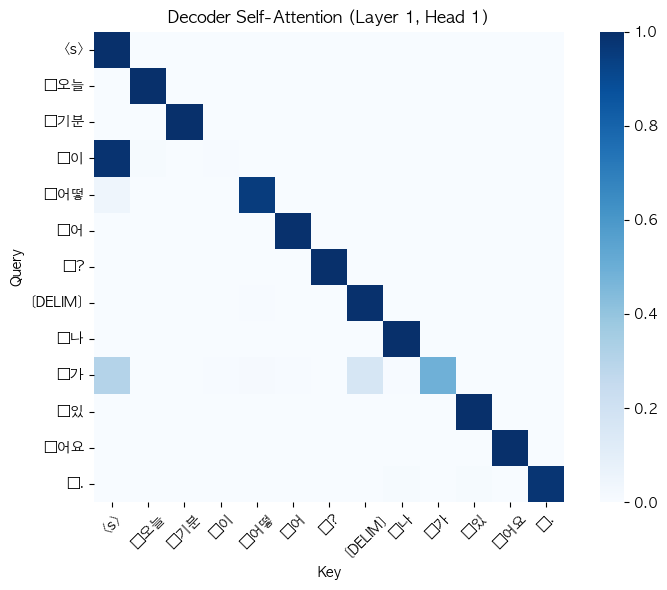

In [32]:
# =========================================
# 10. BLEU 평가 + Attention 시각화
# 생성 답변과 정답의 유사도를 BLEU로 측정하고, Attention 히트맵을 그립니다.
# =========================================
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    """참조 문장과 생성 문장 간 BLEU 점수 (0~1, 높을수록 유사)."""
    return sentence_bleu([reference], candidate, weights=weights,
                         smoothing_function=SmoothingFunction().method1)

def eval_bleu_one(src_text, tgt_text, verbose=True):
    """한 개의 (질문, 정답) 쌍에 대해 모델이 생성한 답과 정답의 BLEU 계산."""
    model.eval()
    pred = reply_greedy(src_text)
    ref = tgt_text.split()
    hyp = pred.split()
    score = calculate_bleu(ref, hyp)
    if verbose:
        print("Source :", src_text)
        print("Target :", tgt_text)
        print("Pred   :", pred)
        print("BLEU   :", score)
    return score

def eval_bleu(src_list, tgt_list, verbose=False):
    """질문/정답 리스트 전체에 대해 평균 BLEU 점수를 구함."""
    total = 0.0
    n = len(src_list)
    for i in tqdm(range(n), desc="eval_bleu"):
        s = eval_bleu_one(src_list[i], tgt_list[i], verbose=verbose)
        total += s
    avg = total / n if n else 0.0
    if not verbose:
        print(f"평균 BLEU: {avg:.4f} (n={n})")
    return avg

print("=== BLEU 예시 (처음 3개만) ===")
for i in range(3):
    src = df["Q_clean"].iloc[i]
    tgt = df["A_clean"].iloc[i]
    eval_bleu_one(src, tgt)

# 전체 데이터 평균 BLEU: eval_bleu(df["Q_clean"].tolist(), df["A_clean"].tolist(), verbose=False)

# 아래: 예시 질문 하나에 대해 답변 생성 후 Decoder Self-Attention 히트맵 출력
q = "오늘 기분이 어때?"
pred, src_p, tgt_p, dec_attns, seq_pieces = generate_with_attention(q)
print("Q:", q)
print("A:", pred)
visualize_attention(seq_pieces, dec_attns)
# 변경: GPT는 Decoder Self-Attention만 시각화 (encdec 제거)
